# **1. Objective**

The purpose of this notebook is to perform diagnostic evaluation
of the best-performing forecasting model.

The analysis includes:

1. Prediction accuracy visualization  
2. Residual distribution analysis  
3. Residual autocorrelation  
4. Feature importance interpretation  

This step validates the robustness and reliability of the forecasting framework.


# **2. Data Preparation**   

The processed winter dataset is loaded and lag/rolling features
are reconstructed exactly as in previous notebooks to ensure consistency.

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

sns.set_style("whitegrid")
plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "axes.labelweight": "bold",
})

In [47]:
df = pd.read_csv("../data/processed/winter_2021_2026.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").set_index("date")

df_model = df.copy()
df_model["tavg"] = pd.to_numeric(df_model["tavg"], errors="coerce")

for lag in range(1, 8):
    df_model[f"lag_{lag}"] = df_model["tavg"].shift(lag)

df_model["rolling_mean_3"] = df_model["tavg"].rolling(3).mean().shift(1)
df_model["rolling_mean_7"] = df_model["tavg"].rolling(7).mean().shift(1)
df_model["rolling_std_7"] = df_model["tavg"].rolling(7).std().shift(1)

features = [col for col in df_model.columns 
            if col.startswith("lag_") or col.startswith("rolling")]

df_model = df_model[["tavg"] + features].dropna().copy()

# **3. Train-Test Split**

A chronological split is applied.

1. Training set: earlier observations  
2. Test set: final 90 days  
3. No random sampling is used  


In [48]:
train = df_model.iloc[:-90]
test = df_model.iloc[-90:]

X_train = train[features]
y_train = train["tavg"]

X_test = test[features]
y_test = test["tavg"]

# **4. Final Model Training**

The best-performing model from Notebook 04 is retrained
using the full training set.

**Although Lasso achieved the lowest RMSE, the improvement over
standard Linear Regression is negligible (≈0.001).**

Given the comparable performance and superior interpretability,
Lag Linear Regression is selected as the final model.



In [49]:
model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse_final = np.sqrt(mean_squared_error(y_test, y_pred))
rmse_final

np.float64(2.840655070147019)

# **5. Prediction vs Actual**

Visual comparison of predicted and observed values
provides intuitive assessment of forecasting quality.

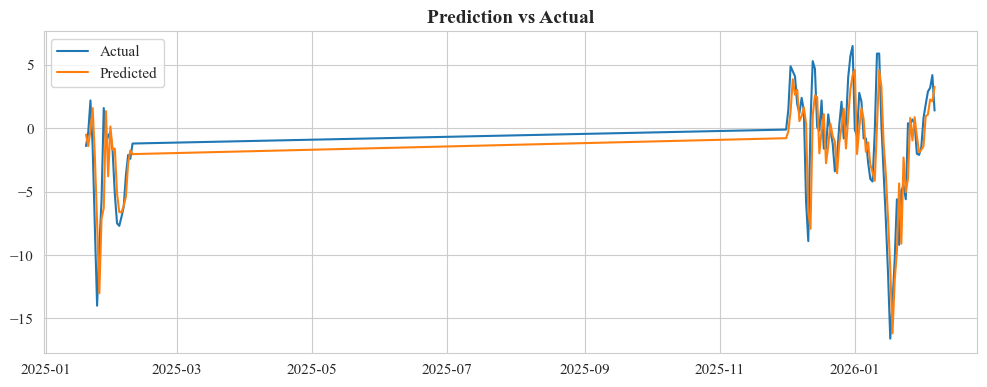

In [50]:
plt.figure(figsize=(10,4))
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, y_pred, label="Predicted")

plt.title("Prediction vs Actual")
plt.legend()
plt.tight_layout()
plt.show()  

# **6. Residual Analysis**

Residuals are defined as:

Residual = Actual − Predicted

We examine:

1. Distribution symmetry  
2. Mean close to zero  
3. Presence of large outliers  


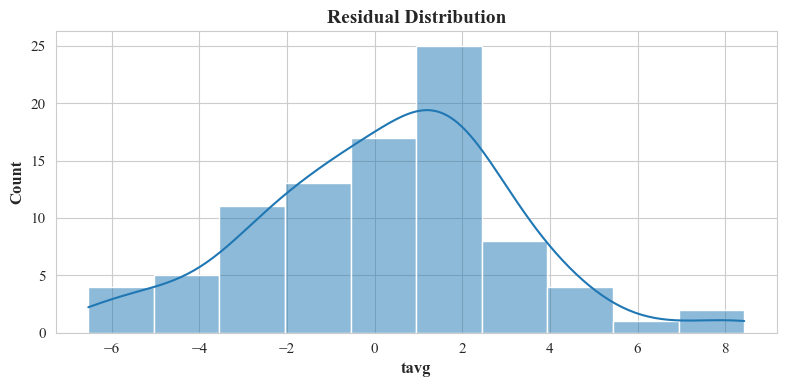

count    90.000000
mean      0.277043
std       2.842951
min      -6.537370
25%      -1.478177
50%       0.654988
75%       1.979726
max       8.435097
Name: tavg, dtype: float64

In [51]:
residuals = y_test - y_pred

plt.figure(figsize=(8,4))
sns.histplot(residuals, kde=True)

plt.title("Residual Distribution")
plt.tight_layout()
plt.show()

residuals.describe()

# **7. Residuals Over Time**

Residuals should fluctuate randomly around zero.
Structured patterns may indicate model misspecification.

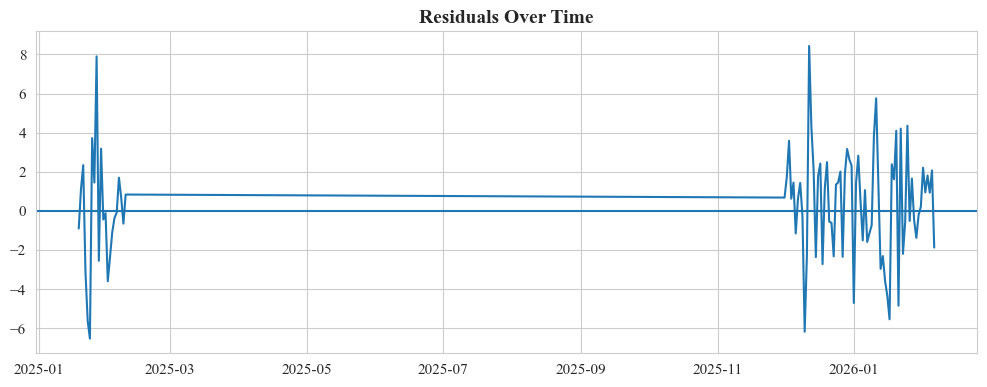

In [52]:
plt.figure(figsize=(10,4))
plt.plot(y_test.index, residuals)

plt.axhline(0)
plt.title("Residuals Over Time")
plt.tight_layout()
plt.show()

# **8. Residual Autocorrelation**

Autocorrelation of residuals is examined to verify
that temporal structure has been adequately captured.

<Figure size 800x400 with 0 Axes>

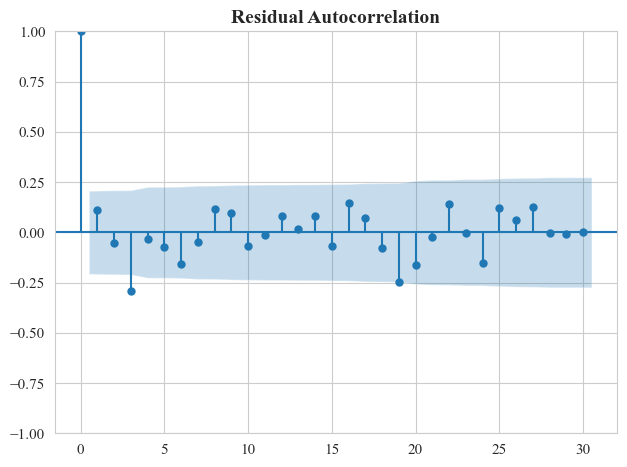

In [53]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(8,4))
plot_acf(residuals, lags=30)

plt.title("Residual Autocorrelation")
plt.tight_layout()
plt.show()

# **9. Feature Importance**

Feature importance analysis identifies
which predictors contribute most to forecasting performance.

In [54]:
coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
}).sort_values("Coefficient", ascending=False)

coef_df

,Feature,Coefficient
0,lag_1,0.900461
7,rolling_mean_3,0.217773
2,lag_3,0.178263
4,lag_5,0.107653
8,rolling_mean_7,0.066163
6,lag_7,-0.023756
5,lag_6,-0.090060
3,lag_4,-0.184016
9,rolling_std_7,-0.262223
1,lag_2,-0.425404


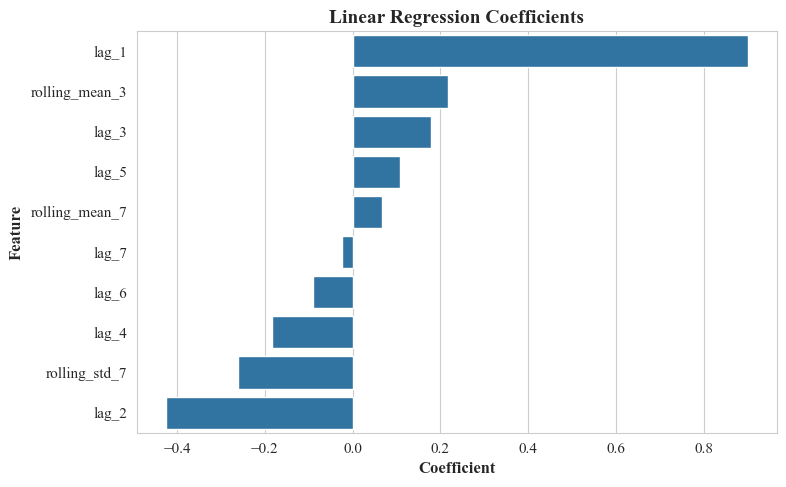

In [55]:
plt.figure(figsize=(8,5))
sns.barplot(data=coef_df,
            x="Coefficient",
            y="Feature")

plt.title("Linear Regression Coefficients")
plt.tight_layout()
plt.show()

# **10. Final Conclusions**

The diagnostic analysis confirms that:

1. Residuals are centered near zero.  
2. No strong autocorrelation remains.  
3. The model captures short-term temperature persistence.  
4. Recent lag features dominate predictive importance.  

The forecasting framework is statistically consistent
and methodologically sound.